R0                     = 3.000
latent period          = 5.0 d   infectious period = 10.0 d
growth rate r          = 0.1000 /d  (doubling time 6.93 d)
R0 recovered from r    = 3.000
peak prevalence I      = 196.7 at t = 74.3
S at peak / (N/R0)     = 275.8 / 333.3
attack rate (sim)      = 0.9406
attack rate (theory)   = 0.9405
max |S+E+I+R - N|      = 3.41e-13


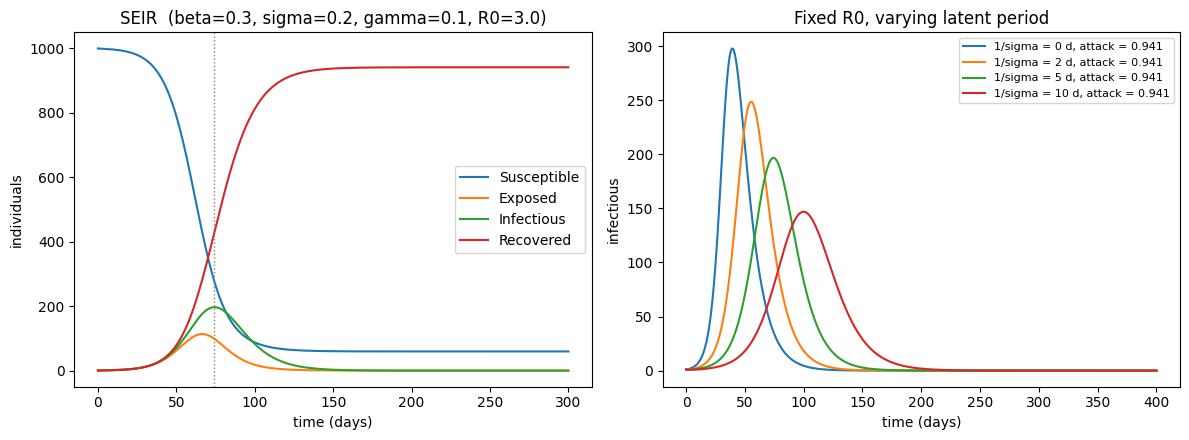

In [ ]:
"""
SEIR compartmental model — SIR plus a latent (exposed, not yet infectious) class.

    dS/dt = -beta * S * I / N
    dE/dt =  beta * S * I / N - sigma * E
    dI/dt =  sigma * E         - gamma * I
    dR/dt =  gamma * I

sigma is the rate of progression E -> I, so 1/sigma is the mean latent period.
Setting sigma -> inf recovers the SIR model.
"""

import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
import matplotlib.pyplot as plt


def seir_rhs(t, y, beta, sigma, gamma, N):
    """Right-hand side of the SEIR system. y = (S, E, I, R)."""
    S, E, I, R = y
    force_of_infection = beta * I / N     # only I transmits, not E
    new_infections = force_of_infection * S
    new_infectious = sigma * E            # end of latency
    new_recoveries = gamma * I
    return [
        -new_infections,
        new_infections - new_infectious,
        new_infectious - new_recoveries,
        new_recoveries,
    ]


def simulate(beta=0.3, sigma=0.2, gamma=0.1, N=1_000, E0=0.0, I0=1.0,
             t_end=300.0, method="RK45"):
    y0 = [N - E0 - I0, E0, I0, 0.0]
    sol = solve_ivp(
        seir_rhs,
        t_span=(0.0, t_end),
        y0=y0,
        args=(beta, sigma, gamma, N),
        t_eval=np.linspace(0.0, t_end, 2000),
        method=method,
        rtol=1e-8,
        atol=1e-10,
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol


def growth_rate(beta, sigma, gamma):
    """Dominant eigenvalue of the linearised (E, I) subsystem at the disease-free state."""
    return 0.5 * (-(sigma + gamma) + np.sqrt((sigma - gamma) ** 2 + 4.0 * sigma * beta))


def r0_from_growth_rate(r, sigma, gamma):
    """Invert growth_rate: recover R0 from an observed exponential growth rate."""
    return (1.0 + r / sigma) * (1.0 + r / gamma)


def final_size(R0):
    """Attack rate: solves 1 - z = exp(-R0 * z). Identical to the SIR result."""
    if R0 <= 1.0:
        return 0.0
    return brentq(lambda z: 1.0 - z - np.exp(-R0 * z), 1e-12, 1.0 - 1e-12)


if __name__ == "__main__":
    beta, sigma, gamma, N = 0.3, 0.2, 0.1, 1_000
    R0 = beta / gamma

    sol = simulate(beta=beta, sigma=sigma, gamma=gamma, N=N)
    S, E, I, R = sol.y

    peak = int(np.argmax(I))
    r = growth_rate(beta, sigma, gamma)

    print(f"R0                     = {R0:.3f}")
    print(f"latent period          = {1 / sigma:.1f} d   infectious period = {1 / gamma:.1f} d")
    print(f"growth rate r          = {r:.4f} /d  (doubling time {np.log(2) / r:.2f} d)")
    print(f"R0 recovered from r    = {r0_from_growth_rate(r, sigma, gamma):.3f}")
    print(f"peak prevalence I      = {I[peak]:.1f} at t = {sol.t[peak]:.1f}")
    print(f"S at peak / (N/R0)     = {S[peak]:.1f} / {N / R0:.1f}")
    print(f"attack rate (sim)      = {R[-1] / N:.4f}")
    print(f"attack rate (theory)   = {final_size(R0):.4f}")
    print(f"max |S+E+I+R - N|      = {np.max(np.abs(S + E + I + R - N)):.2e}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    ax = axes[0]
    for series, label in zip(sol.y, ["Susceptible", "Exposed", "Infectious", "Recovered"]):
        ax.plot(sol.t, series, label=label)
    ax.axvline(sol.t[peak], color="grey", ls=":", lw=1)
    ax.set_xlabel("time (days)")
    ax.set_ylabel("individuals")
    ax.set_title(f"SEIR  (beta={beta}, sigma={sigma}, gamma={gamma}, R0={R0:.1f})")
    ax.legend()

    # Same R0, varying latent period: same final size, different timing.
    ax = axes[1]
    for sig in [10.0, 0.5, 0.2, 0.1]:
        s = simulate(beta=beta, sigma=sig, gamma=gamma, N=N, t_end=300.0)
        ax.plot(s.t, s.y[2], label=f"1/sigma = {1 / sig:.0f} d, attack = {s.y[3][-1] / N:.3f}")
    ax.set_xlabel("time (days)")
    ax.set_ylabel("infectious")
    ax.set_title("Fixed R0, varying latent period")
    ax.legend(fontsize=8)

    fig.tight_layout()
    fig.savefig("seir.png", dpi=150)

1D acceptance 0.575 | mean 1.101 | ESS 860
2D acceptance 0.460 | mean [ 0.05006981 -0.06973553]


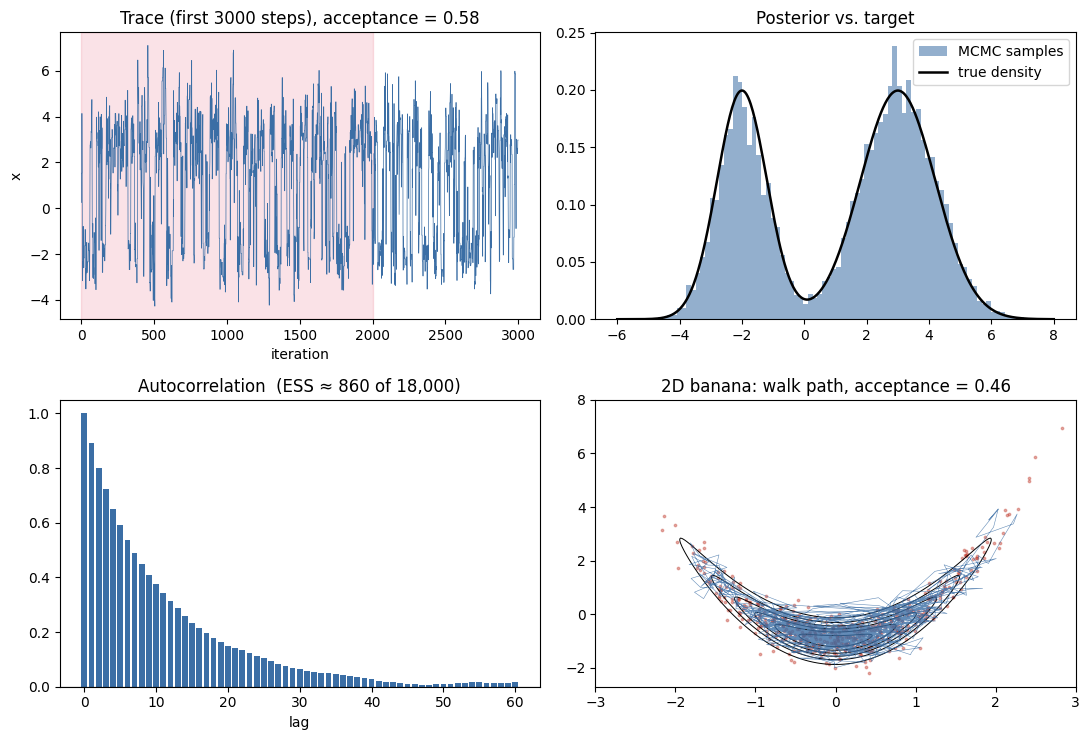

In [1]:
# mcmc

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

def log_target_1d(x):
    """Unnormalised log density: mixture of N(-2, 0.8^2) and N(3, 1.2^2)."""
    a = -0.5 * ((x + 2.0) / 0.8) ** 2 - np.log(0.8)
    b = -0.5 * ((x - 3.0) / 1.2) ** 2 - np.log(1.2)
    return np.logaddexp(np.log(0.4) + a, np.log(0.6) + b)

def log_target_2d(z):
    """Rosenbrock-style 'banana': curved, strongly correlated target."""
    x, y = z[0], z[1]
    return -(x ** 2) / 2.0 - ((y - x**2 + 1.0) ** 2) / 0.4


def rw_metropolis(log_p, x0, n_steps, step_size, rng):
    """Symmetric random-walk proposal => acceptance ratio is just the density ratio."""
    x = np.asarray(x0, dtype=float)
    dim = x.shape
    chain = np.empty((n_steps,) + dim)
    logp = log_p(x)
    n_accept = 0

    for t in range(n_steps):
        prop = x + step_size * rng.standard_normal(dim)
        logp_prop = log_p(prop)
        # accept with prob min(1, p(prop)/p(x)); compare in log space
        r = logp_prop - logp
        if r > np.log(rng.random()):
            x, logp = prop, logp_prop
            n_accept += 1
        chain[t] = x

    return chain, n_accept / n_steps


n_steps, burn_in = 20_000, 2_000
chain1d, acc1d = rw_metropolis(log_target_1d, np.array([0.0]), n_steps, 2.0, rng)
samples1d = chain1d[burn_in:, 0]

chains2d, acc2d = rw_metropolis(log_target_2d, np.array([0.0, 0.0]), n_steps, 0.55, rng)
samples2d = chains2d[burn_in:]

def autocorr(x, max_lag=60):
    x = x - x.mean()
    full = np.correlate(x, x, mode="full")[len(x) - 1:]
    return (full / full[0])[: max_lag + 1]


ac = autocorr(samples1d)
ess = len(samples1d) / (1 + 2 * ac[1:].clip(min=0).sum())

# plotting
# ---------------------------------------------------------------- plots
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))

ax = axes[0, 0]
ax.plot(chain1d[:3000, 0], lw=0.5, color="#3b6ea5")
ax.axvspan(0, burn_in, color="crimson", alpha=0.12)
ax.set_title(f"Trace (first 3000 steps), acceptance = {acc1d:.2f}")
ax.set_xlabel("iteration"); ax.set_ylabel("x")

ax = axes[0, 1]
grid = np.linspace(-6, 8, 400)
dens = np.exp(log_target_1d(grid))
dens /= np.trapezoid(dens, grid)
ax.hist(samples1d, bins=80, density=True, alpha=0.55, color="#3b6ea5", label="MCMC samples")
ax.plot(grid, dens, "k-", lw=1.8, label="true density")
ax.set_title("Posterior vs. target"); ax.legend()

ax = axes[1, 0]
ax.bar(np.arange(len(ac)), ac, color="#3b6ea5")
ax.axhline(0, color="k", lw=0.8)
ax.set_title(f"Autocorrelation  (ESS ≈ {ess:,.0f} of {len(samples1d):,})")
ax.set_xlabel("lag")

ax = axes[1, 1]
gx, gy = np.meshgrid(np.linspace(-3, 3, 300), np.linspace(-2, 8, 300))
ax.contour(gx, gy, np.exp(log_target_2d(np.stack([gx, gy]))), levels=6, colors="k", linewidths=0.7)
ax.plot(samples2d[:1500, 0], samples2d[:1500, 1], lw=0.4, color="#3b6ea5", alpha=0.8)
ax.scatter(samples2d[::40, 0], samples2d[::40, 1], s=3, color="#c0392b", alpha=0.4)
ax.set_title(f"2D banana: walk path, acceptance = {acc2d:.2f}")

fig.tight_layout()
fig.savefig("random_walk.png", dpi=150)

print(f"1D acceptance {acc1d:.3f} | mean {samples1d.mean():.3f} | ESS {ess:.0f}")
print(f"2D acceptance {acc2d:.3f} | mean {samples2d.mean(0)}")


acceptance 0.37
beta_0: true -0.70 | mean -0.82 | 95% CI [-1.15, -0.51]
beta_1: true +1.90 | mean +1.73 | 95% CI [+1.29, +2.22]
beta_2: true -1.20 | mean -1.04 | 95% CI [-1.42, -0.69]


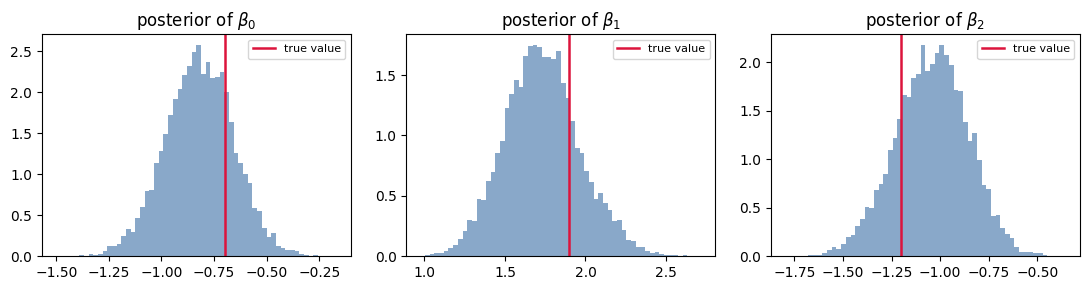

In [3]:
"""The target is never handed to us — it is assembled from data + model."""

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(1)
#  ---- data we observe (in reality: measurements; here: synthetic so we can check)
n, d = 300, 3 # 3 thetas
X = np.column_stack([np.ones(n), rng.standard_normal((n, d - 1))])
beta_true = np.array([-0.7, 1.9, -1.2])
y = rng.random(n) < 1.0 / (1.0 + np.exp(-X @ beta_true))

def log_posterior(beta):
    """log p(beta | X, y)  +  const.

    We cannot draw from this, we cannot integrate it, we do not know its
    normalising constant. We can only *evaluate* it at any point we like --
    which is all Metropolis-Hastings ever needs.
    """
    z = X @ beta
    log_lik = np.sum(y * z - np.logaddexp(0.0, z))   # Bernoulli log-likelihood
    log_prior = -0.5 * np.sum(beta**2) / 5.0**2      # N(0, 5^2) prior
    return log_lik + log_prior

chain, acc = rw_metropolis(log_posterior, np.zeros(d), 40_000, 0.22, rng)
post = chain[5_000:]  # discard burn-in

print(f"acceptance {acc:.2f}")
for j in range(d):
    lo, hi = np.percentile(post[:, j], [2.5, 97.5])
    print(f"beta_{j}: true {beta_true[j]:+.2f} | mean {post[:, j].mean():+.2f} | 95% CI [{lo:+.2f}, {hi:+.2f}]")

fig, axes = plt.subplots(1, d, figsize=(11, 3))
for j, ax in enumerate(axes):
    ax.hist(post[:, j], bins=60, density=True, color="#3b6ea5", alpha=0.6)
    ax.axvline(beta_true[j], color="crimson", lw=1.8, label="true value")
    ax.set_title(f"posterior of $\\beta_{j}$")
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig("bayes_logreg.png", dpi=140)

Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/athapar/personal/ai-bio-projects/.venv/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 497, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/athapar/personal/ai-bio-projects/.venv/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 348, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/athapar/personal/ai-bio-projects/.venv/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:126: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE


banana    HMC: acc 0.87  ESS(x)    430/5000  0.11s
banana     RW: acc 0.42  ESS(x)     20/5000  0.01s
logreg    HMC: acc 0.84  ESS per coord  1038  1200  1056
logreg     RW: acc 0.37  ESS per coord   300   156   292
logreg HMC posterior mean: [-0.83  1.74 -1.04]  true: [-0.7  1.9 -1.2]


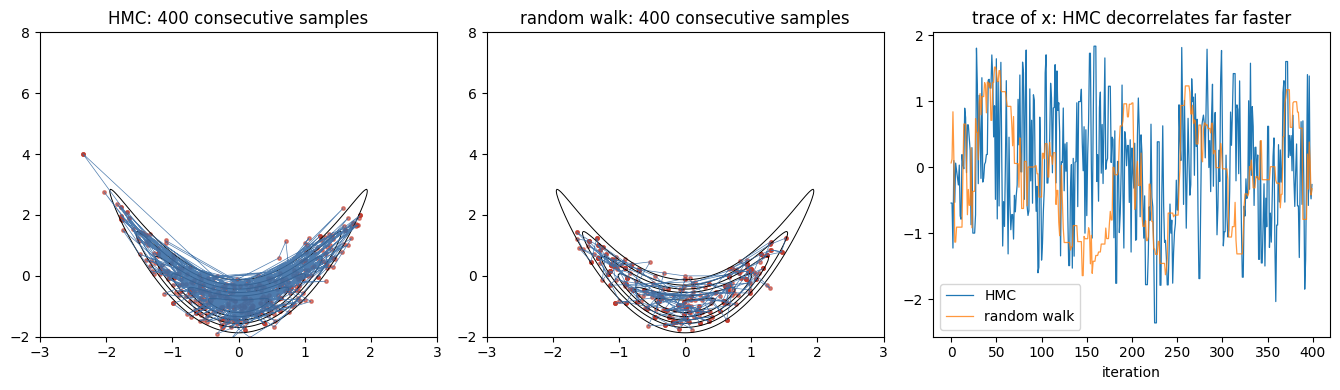

In [3]:
"""Hamiltonian Monte Carlo from scratch in JAX.

Notation
    q            position   = the parameters we want samples of
    r            momentum   = auxiliary variable, r ~ N(0, I)
    U(q)         potential energy  = -log p(q)
    K(r)         kinetic energy    = ½ rᵀr
    H(q, r)      total energy      = U(q) + K(r)

Since exp(-H) = p(q) · N(r; 0, I), sampling (q, r) and dropping r gives q ~ p(q).

Hamilton's equations (these keep H constant):
    dq/dt =  ∂H/∂r =  r
    dr/dt = -∂H/∂q = -∇U(q)

One HMC iteration, starting at q:
    1. sample   r ~ N(0, I)
    2. simulate (q*, r*) = Leapfrog(q, r)  for L steps of size ε
    3. accept q* with probability  α = min(1, exp(H(q, r) - H(q*, r*)))
"""

import time
import jax
import jax.numpy as jnp
from jax import lax, random
import numpy as np
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)


# ================================================================== leapfrog
def leapfrog(grad_U, q, r, eps, L):
    """Approximately solve  dq/dt = r,  dr/dt = -∇U(q)  for time L·ε.

    Each step t -> t+ε:
        r_{t+ε/2} = r_t       - (ε/2) ∇U(q_t)        half step in momentum
        q_{t+ε}   = q_t       +  ε    r_{t+ε/2}      full step in position
        r_{t+ε}   = r_{t+ε/2} - (ε/2) ∇U(q_{t+ε})    half step in momentum

    Leapfrog is reversible and volume preserving, which is what makes
    the accept/reject in step 3 exact.
    """
    for _ in range(L):  # plain Python loop: jit unrolls it into L steps
        r = r - (eps / 2) * grad_U(q)
        q = q + eps * r
        r = r - (eps / 2) * grad_U(q)
    return q, r


# ======================================================================= hmc
def hmc(log_p, q0, n_samples, eps, L, key):
    U = lambda q: -log_p(q)                          # U(q) = -log p(q)
    K = lambda r: 0.5 * jnp.sum(r**2)                # K(r) = ½ rᵀr
    H = lambda q, r: U(q) + K(r)                     # H = U + K
    grad_U = jax.grad(U)                             # ∇U(q)

    def one_iteration(q, key):
        key_r, key_u = random.split(key)

        # 1. r ~ N(0, I)
        r = random.normal(key_r, q.shape)

        # 2. (q*, r*) = Leapfrog(q, r)
        q_star, r_star = leapfrog(grad_U, q, r, eps, L)

        # 3. accept if  u < α,  u ~ Uniform(0, 1)   (in log space)
        log_alpha = H(q, r) - H(q_star, r_star)
        accept = jnp.log(random.uniform(key_u)) < log_alpha
        q_next = jnp.where(accept, q_star, q)

        return q_next, (q_next, accept)              # (carry, recorded output)

    # run  q_1, ..., q_n  by repeating one_iteration (lax.scan = a compiled for-loop)
    keys = random.split(key, n_samples)
    _, (samples, accepted) = lax.scan(one_iteration, q0, keys)
    return samples, accepted.mean()


# log_p and L change the program's structure, so jit treats them as static
hmc = jax.jit(hmc, static_argnames=("log_p", "n_samples", "L"))


# =================================================================== targets
def log_banana(z):
    """Curved, correlated 2D target."""
    x, y = z[0], z[1]
    return -(x**2) / 2.0 - ((y - x**2 + 1.0) ** 2) / 0.4


# Bayesian logistic regression (same data as the earlier cell, written in jnp so grad works)
rng = np.random.default_rng(1)
n, d = 300, 3
X = jnp.asarray(np.column_stack([np.ones(n), rng.standard_normal((n, d - 1))]))
beta_true = np.array([-0.7, 1.9, -1.2])
y = jnp.asarray(rng.random(n) < 1.0 / (1.0 + np.exp(-np.asarray(X) @ beta_true))).astype(float)


def log_posterior(beta):
    z = X @ beta
    log_lik = jnp.sum(y * z - jnp.logaddexp(0.0, z))   # Bernoulli likelihood
    log_prior = -0.5 * jnp.sum(beta**2) / 5.0**2       # N(0, 5²) prior
    return log_lik + log_prior


# =================================================================== helpers
def ess(x, max_lag=200):
    """Effective sample size: n / (1 + 2 Σ autocorrelations)."""
    x = np.asarray(x) - np.asarray(x).mean()
    full = np.correlate(x, x, mode="full")[len(x) - 1:]
    ac = (full / full[0])[: max_lag + 1]
    return len(x) / (1 + 2 * ac[1:].clip(min=0).sum())


def rw_metropolis(log_p, x0, n_steps, step, rng):
    """Random-walk Metropolis baseline for comparison."""
    x = np.asarray(x0, float)
    chain = np.empty((n_steps,) + x.shape)
    logp, n_acc = float(log_p(x)), 0
    for t in range(n_steps):
        prop = x + step * rng.standard_normal(x.shape)
        lp = float(log_p(prop))
        if np.log(rng.random()) < lp - logp:
            x, logp, n_acc = prop, lp, n_acc + 1
        chain[t] = x
    return chain, n_acc / n_steps


# ==================================================================== run it
N = 5_000

hmc(log_banana, jnp.zeros(2), N, 0.2, 15, random.PRNGKey(0))   # first call compiles
t0 = time.time()
ban_hmc, acc_b = hmc(log_banana, jnp.zeros(2), N, 0.2, 15, random.PRNGKey(0))
ban_hmc = np.asarray(ban_hmc)                                    # wait for result
t_hmc = time.time() - t0

t0 = time.time()
ban_rw, acc_rw = rw_metropolis(log_banana, np.zeros(2), N, 0.55, np.random.default_rng(0))
t_rw = time.time() - t0

post_hmc, acc_p = hmc(log_posterior, jnp.zeros(d), N, 0.18, 20, random.PRNGKey(2))
post_hmc = np.asarray(post_hmc)
post_rw, acc_prw = rw_metropolis(log_posterior, np.zeros(d), N, 0.22, np.random.default_rng(3))

print(f"banana    HMC: acc {acc_b:.2f}  ESS(x) {ess(ban_hmc[:, 0]):6.0f}/{N}  {t_hmc:.2f}s")
print(f"banana     RW: acc {acc_rw:.2f}  ESS(x) {ess(ban_rw[:, 0]):6.0f}/{N}  {t_rw:.2f}s")
print(f"logreg    HMC: acc {acc_p:.2f}  ESS per coord " + " ".join(f"{ess(post_hmc[:, j]):5.0f}" for j in range(d)))
print(f"logreg     RW: acc {acc_prw:.2f}  ESS per coord " + " ".join(f"{ess(post_rw[:, j]):5.0f}" for j in range(d)))
print("logreg HMC posterior mean:", post_hmc[500:].mean(0).round(2), " true:", beta_true)

# ====================================================================== plot
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))
gx, gy = np.meshgrid(np.linspace(-3, 3, 300), np.linspace(-2, 8, 300))
dens = np.exp(np.asarray(jax.vmap(jax.vmap(log_banana))(jnp.stack([gx, gy], -1))))

for ax, chain, name in ((axes[0], ban_hmc, "HMC"), (axes[1], ban_rw, "random walk")):
    ax.contour(gx, gy, dens, levels=6, colors="k", linewidths=0.7)
    ax.plot(chain[:400, 0], chain[:400, 1], lw=0.5, color="#3b6ea5", alpha=0.9)
    ax.scatter(chain[:400, 0], chain[:400, 1], s=6, color="#c0392b", alpha=0.6)
    ax.set_title(f"{name}: 400 consecutive samples")
    ax.set_xlim(-3, 3); ax.set_ylim(-2, 8)

axes[2].plot(ban_hmc[:400, 0], lw=0.9, label="HMC")
axes[2].plot(ban_rw[:400, 0], lw=0.9, alpha=0.8, label="random walk")
axes[2].set_title("trace of x: HMC decorrelates far faster")
axes[2].set_xlabel("iteration"); axes[2].legend()

fig.tight_layout()
fig.savefig("hmc.png", dpi=140)

acceptance per chain: [0.71 0.74 0.88 0.88 0.88]
x: R-hat 1.001 | chain means [-0.08 -0.04 -0.13 -0.03 -0.05] | total ESS 846
y: R-hat 1.000 | chain means [-0.13 -0.18 -0.06 -0.16 -0.15] | total ESS 989


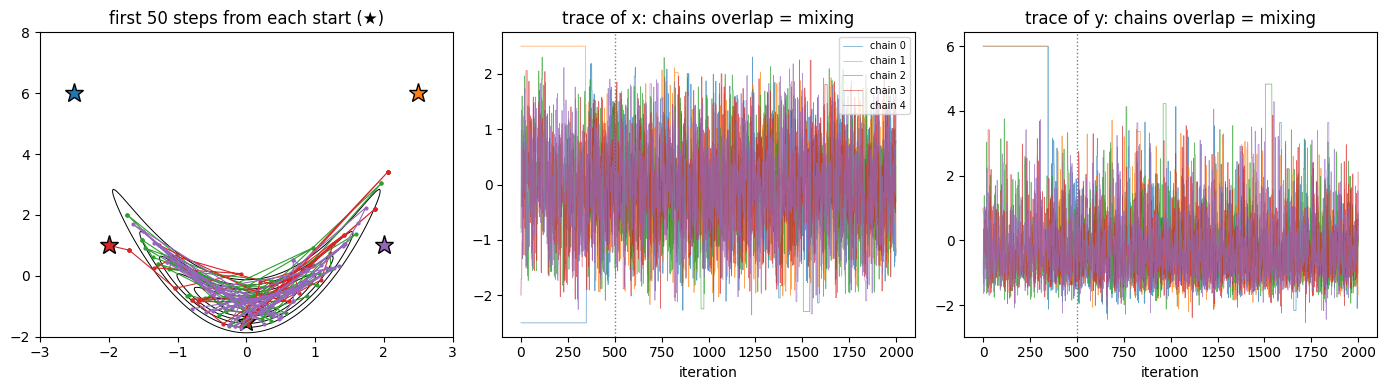

In [4]:
"""Run 5 HMC chains in parallel from spread-out starting points and check they mix.

If every chain, starting from a different place, ends up exploring the same
region with the same statistics, we have evidence the sampler has converged.
Numeric check: R-hat = sqrt(total variance / within-chain variance)  ->  ≈ 1.
"""

n_chains, N = 5, 2_000

# deliberately spread-out (overdispersed) starting points on the banana
q0s = jnp.array([[-2.5, 6.0], [2.5, 6.0], [0.0, -1.5], [-2.0, 1.0], [2.0, 1.0]])
keys = random.split(random.PRNGKey(42), n_chains)

# vmap = run the same hmc once per (q0, key) pair, all in one compiled call
run_chains = jax.vmap(lambda q0, key: hmc(log_banana, q0, N, 0.2, 15, key))
chains, accs = run_chains(q0s, keys)          # chains: (n_chains, N, 2)
chains = np.asarray(chains)


def r_hat(x):
    """Gelman-Rubin R-hat for x of shape (n_chains, n_samples)."""
    m, n = x.shape
    W = x.var(axis=1, ddof=1).mean()                # mean within-chain variance
    B = n * x.mean(axis=1).var(ddof=1)              # between-chain variance
    var_total = (n - 1) / n * W + B / n
    return np.sqrt(var_total / W)


# chains starting far out (★ at y=6) get rejected for a few hundred steps before they
# find the banana (flat lines in the traces), so discard enough warm-up to drop that
burn = 500
kept = chains[:, burn:]
print("acceptance per chain:", np.asarray(accs).round(2))
for j, name in enumerate(["x", "y"]):
    means = kept[:, :, j].mean(axis=1).round(2)
    total_ess = sum(ess(kept[c, :, j]) for c in range(n_chains))
    print(f"{name}: R-hat {r_hat(kept[:, :, j]):.3f} | chain means {means} | total ESS {total_ess:.0f}")

# ---------------------------------------------------------------------- plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = plt.cm.tab10(np.arange(n_chains))

ax = axes[0]
ax.contour(gx, gy, dens, levels=6, colors="k", linewidths=0.7)
for c in range(n_chains):
    ax.plot(chains[c, :50, 0], chains[c, :50, 1], "-o", ms=2, lw=0.8, color=colors[c])
    ax.plot(*q0s[c], "*", ms=14, color=colors[c], mec="k")
ax.set_title("first 50 steps from each start (★)")
ax.set_xlim(-3, 3); ax.set_ylim(-2, 8)

for ax, j, name in ((axes[1], 0, "x"), (axes[2], 1, "y")):
    for c in range(n_chains):
        ax.plot(chains[c, :, j], lw=0.5, alpha=0.7, color=colors[c], label=f"chain {c}")
    ax.axvline(burn, color="grey", ls=":", lw=1)
    ax.set_title(f"trace of {name}: chains overlap = mixing")
    ax.set_xlabel("iteration")
axes[1].legend(fontsize=7, loc="upper right")

fig.tight_layout()
fig.savefig("hmc_chains.png", dpi=140)